# 02 — Group Size & Topology Sweep

How each algorithm's α coefficient scales with G:

| algorithm | α coefficient | source |
|---|---|---|
| ring AR | `2(G-1)` (linear) | `01_collective_algorithms.md` §5.1 |
| DBT AR | `2⌈log₂ G⌉` (log) | `01_collective_algorithms.md` §5.2 |
| Rabenseifner AR | `2⌈log₂ G⌉` (log) | `01_collective_algorithms.md` App. B.2 |
| torus k-D dim-decomp | `2·Σ(d_i - 1)` (cube-root if d_i = G^(1/k)) | `02_topology_mapping.md` §3.4 |
| INC AR | constant 2·α_switch | `04_in_network_collectives.md` §1.4 |

BW coefficients converge to a tight band — only INC AR's BW ceiling differs (BW vs BW/2). At fixed bulk M the α scaling is what reorders the leaderboard as G grows.

## Setup

In [1]:
%matplotlib inline
import sys, math
from pathlib import Path

REPO = Path.cwd().resolve()
while REPO.name != 'collective_comm' and REPO.parent != REPO:
    REPO = REPO.parent
CODE = REPO / 'code'
if str(CODE) not in sys.path:
    sys.path.insert(0, str(CODE))

import pandas as pd
import matplotlib.pyplot as plt

from core import collective_cost as cc
from util import Anchors, sweep, to_us

a = Anchors()
M, alpha, bw = a.M, a.alpha, a.bw
print(f'M={M/1e6:.0f} MB fixed; α={alpha*1e6:.2f} μs, BW={bw/1e9:.0f} GB/s')


M=16 MB fixed; α=0.50 μs, BW=900 GB/s


## AR cost vs G

Sweep G ∈ {8, 16, 32, ..., 8192} at M = 16 MB. Torus is rendered as 3-D (cube-ish factorization) which is the fairest single representative — cubic G^(1/3) per dim minimizes Σ(d_i - 1).

In [2]:
# Choose a torus shape that divides each G evenly: 1-D ring (N), 2-D √N×√N,
# 3-D ∛N × ∛N × ∛N (rounded). For non-cubic G we fall back to nearest factor.
def torus_dims_for(G, k):
    """k-D cube-ish factorization of G. Falls back to a flatter shape if
    G isn't a perfect kth power."""
    root = round(G ** (1.0 / k))
    if root ** k == G:
        return (root,) * k
    # find nearest factorization (greedy: extract roots one dim at a time)
    dims = []
    remaining = G
    for i in range(k - 1):
        d = round(remaining ** (1.0 / (k - i)))
        # adjust so d divides remaining
        while remaining % d != 0 and d > 1:
            d -= 1
        dims.append(d)
        remaining //= d
    dims.append(remaining)
    return tuple(dims)

ar_curves_G = {
    'ring AR':       lambda G: cc.ring_all_reduce(M, G, alpha, bw),
    'DBT AR':        lambda G: cc.tree_all_reduce(M, G, alpha, bw),
    'Rabenseifner':  lambda G: cc.rabenseifner_all_reduce(M, G, alpha, bw),
    'INC AR':        lambda G: cc.inc_all_reduce(M, alpha, bw),
    'torus 3-D':     lambda G: cc.torus_all_reduce(M, torus_dims_for(G, 3), alpha, bw),
}

Gs = [8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]
df_G = sweep(ar_curves_G, Gs, x_name='G')
df_G.head(8)


,G,label,t_us
0,8,ring AR,38.111111
1,8,DBT AR,56.333333
2,8,Rabenseifner,34.111111
3,8,INC AR,18.777778
4,8,torus 3-D,34.111111
5,16,ring AR,48.333333
6,16,DBT AR,75.111111
7,16,Rabenseifner,37.333333


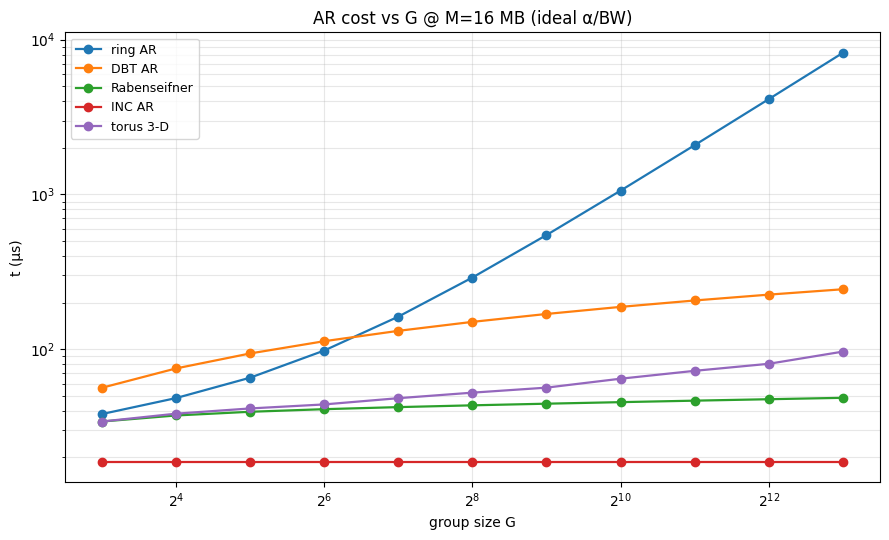

In [3]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for label, sub in df_G.groupby('label', sort=False):
    ax.plot(sub['G'], sub['t_us'], marker='o', label=label, linewidth=1.6)
ax.set_xscale('log', base=2); ax.set_yscale('log')
ax.set_xlabel('group size G'); ax.set_ylabel('t (μs)')
ax.set_title(f'AR cost vs G @ M={M/1e6:.0f} MB (ideal α/BW)')
ax.legend(loc='upper left', fontsize=9); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()


## Torus dimensionality at fixed G

Same N=1024, M=16 MB, but vary how the ranks are arranged on the torus. Decomposing into more dimensions cuts the latency hop count from `2(N-1)·α` (1-D ring) down to `2·Σ(d_i - 1)·α`; the BW coefficient stays at the ring asymptote `2(N-1)/N · M/BW` because the chunked schedule telescopes cleanly across phases (`02_topology_mapping.md` §3.4).

In [4]:
# At fixed G=1024 (cubic-friendly: 32², 8·8·16, 4·4·8·8, ...) sweep
# dimensionality. Latency scales as 2·Σ(d_i - 1)·α, so cube-ish shapes
# dominate.
G_fixed = 1024

dim_options = {
    '1-D ring (N=1024)':      (1024,),
    '2-D 32×32':              (32, 32),
    '3-D 8·8·16':             (8, 8, 16),
    '4-D 4·4·8·8':            (4, 4, 8, 8),
    '5-D 4·4·4·4·4':          (4, 4, 4, 4, 4),
    '10-D 2¹⁰':               (2,) * 10,
}

torus_rows = []
for name, dims in dim_options.items():
    t = cc.torus_all_reduce(M, dims, alpha, bw)
    hops = sum(d - 1 for d in dims)
    torus_rows.append({
        'shape': name,
        'k': len(dims),
        '2·Σ(d-1)·α (μs)':    to_us(2 * hops * alpha),
        '2(N-1)/N · M/BW (μs)': to_us(2 * (G_fixed - 1) / G_fixed * M / bw),
        'total (μs)':         to_us(t),
    })
pd.DataFrame(torus_rows)


,shape,k,2·Σ(d-1)·α (μs),2(N-1)/N · M/BW (μs),total (μs)
0,1-D ring (N=1024),1,1023.0,35.520833,1058.520833
1,2-D 32×32,2,62.0,35.520833,97.520833
2,3-D 8·8·16,3,29.0,35.520833,64.520833
3,4-D 4·4·8·8,4,20.0,35.520833,55.520833
4,5-D 4·4·4·4·4,5,15.0,35.520833,50.520833
5,10-D 2¹⁰,10,10.0,35.520833,45.520833


## A2A cost vs G

All-to-all has fundamentally different scaling: total wire-side bytes are O(N·M), so even with a full-bisection fabric every algorithm pays a `(G-1)/G · M/BW` BW term. Differences are only in the α factor (and in Bruck's `log/2` BW coefficient, which costs more BW than pairwise).

Topology matters more here than for AR: torus A2A is bisection-bound at `d_max·M / (8·BW)` per direction (`02_topology_mapping.md` §3.6), and INC A2A collapses the α side to a single transaction (`04_in_network_collectives.md` §1.3).

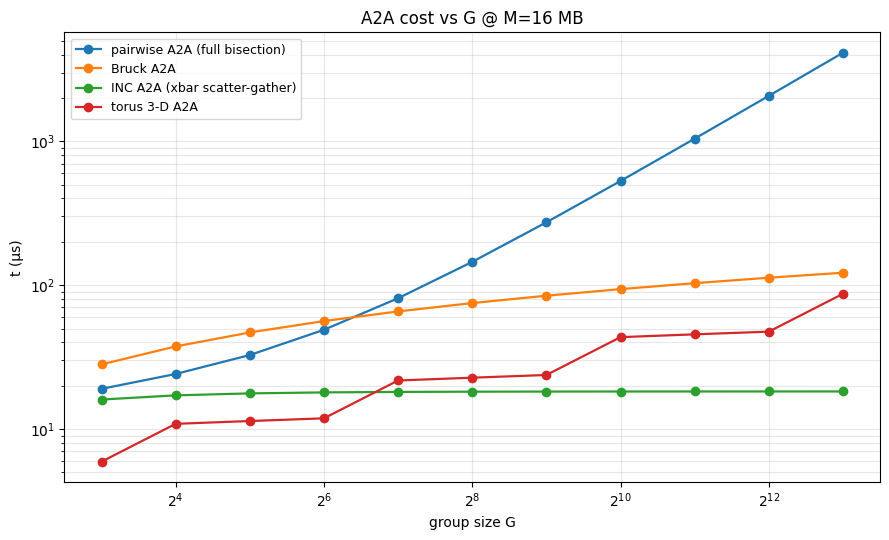

In [5]:
a2a_curves_G = {
    'pairwise A2A (full bisection)':   lambda G: cc.pairwise_a2a(M, G, alpha, bw),
    'Bruck A2A':                       lambda G: cc.bruck_a2a(M, G, alpha, bw),
    'INC A2A (xbar scatter-gather)':   lambda G: cc.inc_a2a(M, G, alpha, bw),
    'torus 3-D A2A':                   lambda G: cc.torus_a2a(
                                            M, torus_dims_for(G, 3), alpha, bw),
}

df_A2A = sweep(a2a_curves_G, Gs, x_name='G')

fig, ax = plt.subplots(figsize=(9, 5.5))
for label, sub in df_A2A.groupby('label', sort=False):
    ax.plot(sub['G'], sub['t_us'], marker='o', label=label, linewidth=1.6)
ax.set_xscale('log', base=2); ax.set_yscale('log')
ax.set_xlabel('group size G'); ax.set_ylabel('t (μs)')
ax.set_title(f'A2A cost vs G @ M={M/1e6:.0f} MB')
ax.legend(loc='upper left', fontsize=9); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()


## Key takeaways

1. **Ring AR scales linearly in G on the α term** — at G=8192 it's ~16,000·α slower than DBT/INC. Becomes useless past N≈64 unless message is huge enough to render α negligible (the regime crossover from notebook 01 reverses).
2. **Torus dim-decomp closes most of the gap to DBT** with cubic shapes: 8³ → 21 hops vs DBT's 9 hops at N=512.
3. **INC AR is the only flat curve** — α stays at `2·α_switch` independent of G as long as the switch ALU has the port budget.
4. **A2A is harder to accelerate than AR**: BW asymptote is fundamental (bisection bandwidth), so even INC A2A only collapses α.